In [1]:
from torchfied_char_mlp_with_bn import ComplexCharMLP
import csv

names = []
with open("../../../resources/indian_names_m.csv", "r", newline='') as file:
    reader = csv.DictReader(file)
    # get all the names from 'name' header
    for row in reader:
        name = row['name']
        # Filter to English characters only (ASCII letters) and spaces
        # english_name = ''.join(c for c in name if c.isalpha() and ord(c) < 128)
        english_name = ''.join(c for c in name if (c.isalpha() or c == ' ') and ord(c) < 128)
        if len(english_name.strip()) > 3:  # Keep names with at least 3 English characters
            names.append(english_name.lower())  # Convert to lowercase for consistency

namesStr = ""
with open("../../../resources/indian_names2.txt", "r", newline='') as file2:
    c = file2.read()
    while c != "":
        namesStr += c.lower()
        c = file2.read()
n2 = namesStr.split(",")
names2 = []
print(len(n2))
for n in n2:
    english_name = ''.join(c for c in n if (c.isalpha() or c == ' ') and ord(c) < 128)
    if len(english_name.strip()) > 3:
        names2.append(english_name.strip())

names += names2


print(f"Total English names loaded: {len(names)}")

model = ComplexCharMLP(names, block_size=3, batch_size=32, debug=True, num_layers=2)
model.layer1_neurons = 100
model.embedding_dim_size = 10
model.reset_parameters()
print(len(model.layers))

7249
Total English names loaded: 21736
Total parameters: 6308
Total layers  6
Layer 0: Embedding(shape=torch.Size([28, 10]))
Layer 2: Linear(shape=torch.Size([30, 100]))
Layer 3: BatchNorm1d(shape=torch.Size([100]))
Layer 5: Linear(shape=torch.Size([100, 28]))
6


In [2]:
model.set_debug(False)
model.train(training_epochs=100)

Epoch 0/100, Loss: 3.3479

=== BatchNorm Running Stats ===
Layer 3 (BatchNorm1d):
  Running mean - mean: 0.9013, std: 0.0324
  Running var  - mean: 0.0995, std: 0.0424
  Gamma (gain) - mean: 1.0000, std: 0.0000
  Beta (bias)  - mean: 0.0000, std: 0.0000


In [5]:
print("dev set loss:", model.loss_on_dev_set())
print("test set loss:", model.loss_on_test_set())

dev set loss: 1.9202044010162354
test set loss: 1.9396388530731201


Tanh Activations distribution
Layer 4 tanh output shape: torch.Size([32, 100]), mean: -0.0011, std: 0.6318, saturation pct: 3.09%


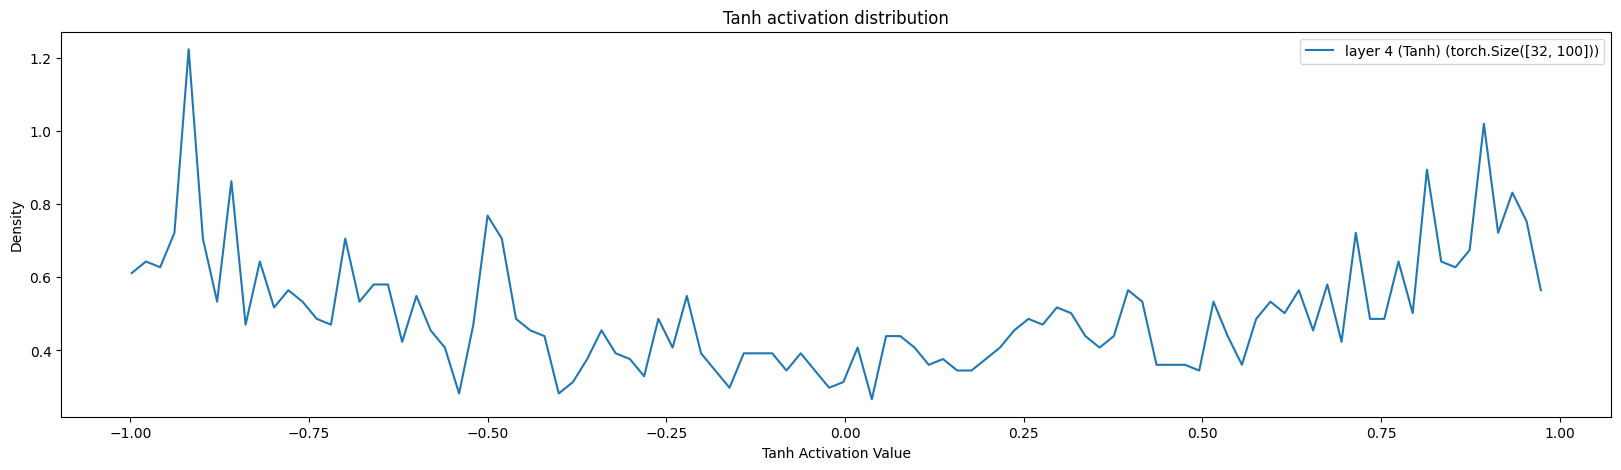


 ----------------------------------------------------------------------------------------------------
Tanh Grads distribution
Layer 4 (Tanh) grad_shape: torch.Size([32, 100]) mean 0.0000 std: 0.0015


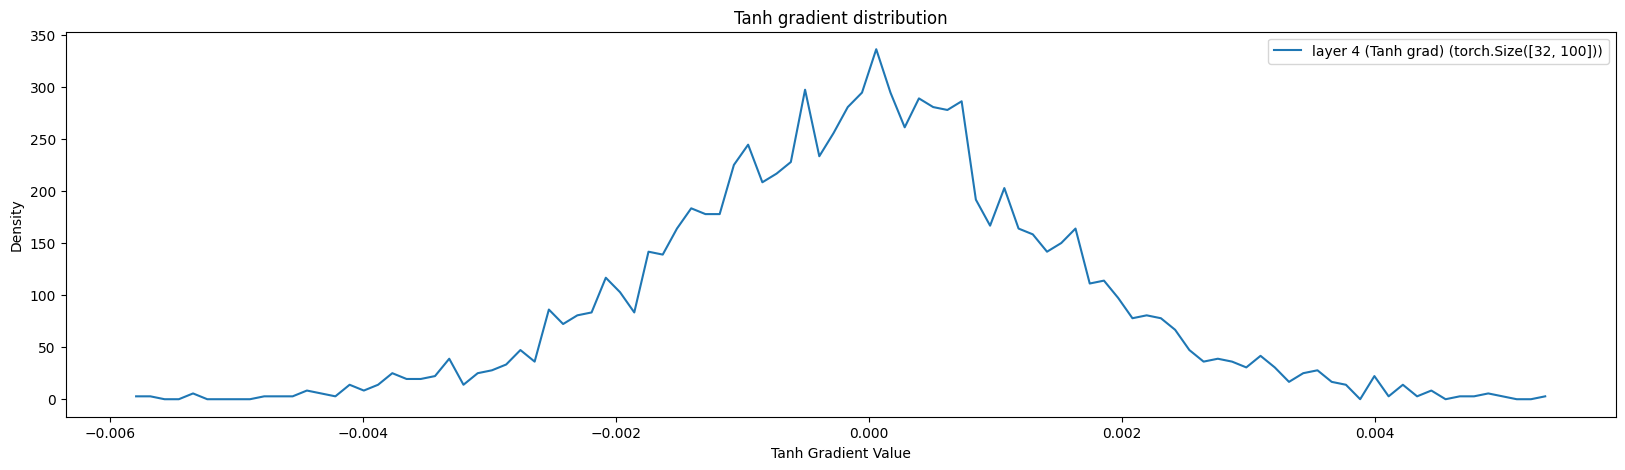


 ----------------------------------------------------------------------------------------------------
Weights grad distribution
Layer 0 weight shape: torch.Size([28, 10]) grad mean: -0.0000 gard std: 0.0069 grad/data ratio: 6.931023e-03
Layer 1 weight shape: torch.Size([30, 100]) grad mean: 0.0001 gard std: 0.0059 grad/data ratio: 3.251608e-02
Layer 4 weight shape: torch.Size([100, 28]) grad mean: -0.0000 gard std: 0.0189 grad/data ratio: 4.652621e-01


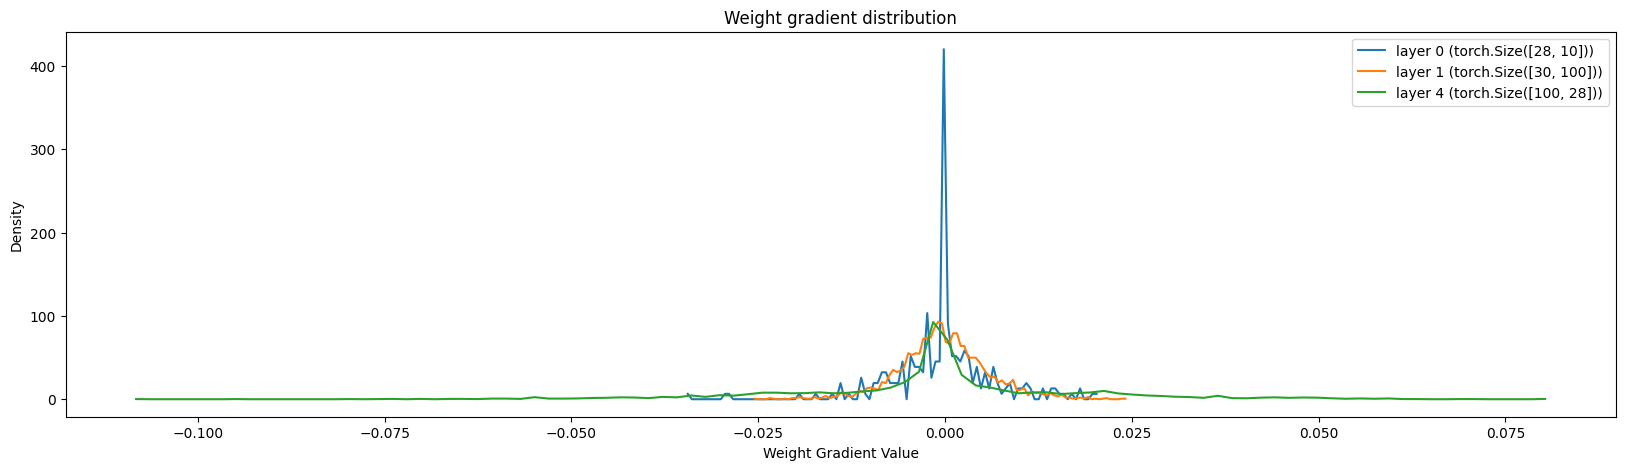


 ----------------------------------------------------------------------------------------------------
Parms Update to data ratio


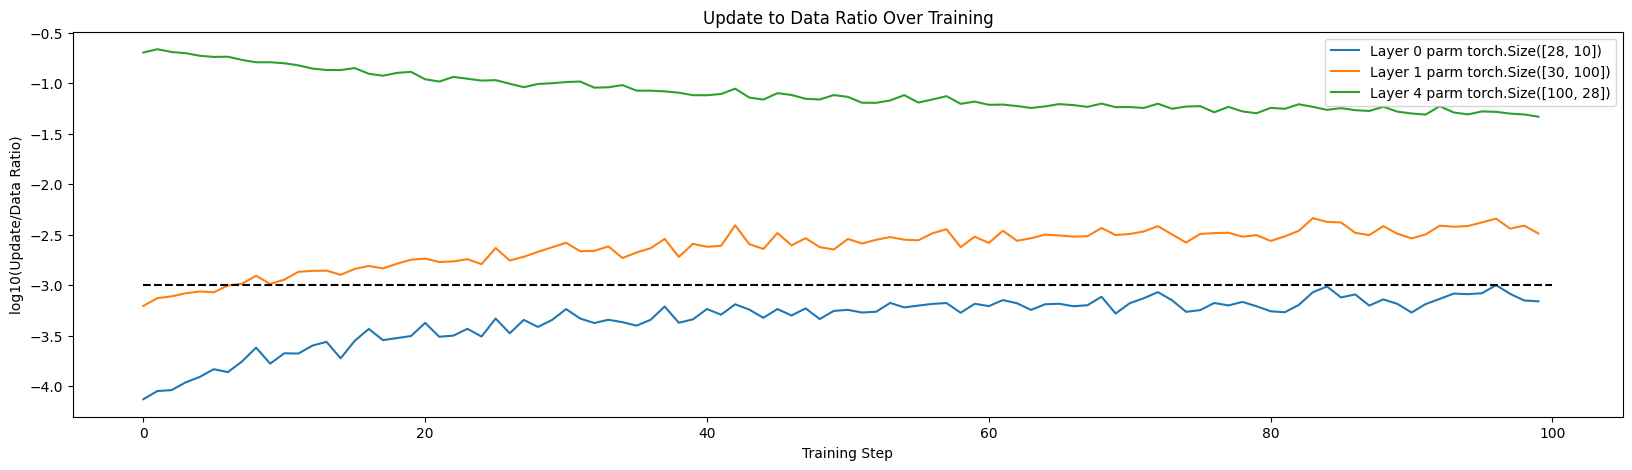


 ----------------------------------------------------------------------------------------------------
Loss across epochs
Self loss shape  100


AttributeError: 'list' object has no attribute 'shape'

In [3]:
model.plot_diagnostic_graphs()

In [14]:
import torch


sample_words = model.sample_words(15)
print(sample_words)
s = set(sample_words)
print(len(sample_words))
# print(len(s))


['sarika', 'dinesh', 'jaswanil', 'ram tiwas', 'mudev singh  banish kumar', 'mohankirkasharma', 'virendeep kumar', 'ramansant', 'samjit gardiketu gulaksharayanaanditendulav', 'ash mukesh vichar', 'sh kumar', 'sunniti', 'dharmendra', 'chand', 'ram lalityagi']
15


histogram counts: tensor([4., 0., 3., 2.])
histogram bins: tensor([1.0000, 1.5000, 2.0000, 2.5000, 3.0000])
unique values: tensor([1., 2., 3.])


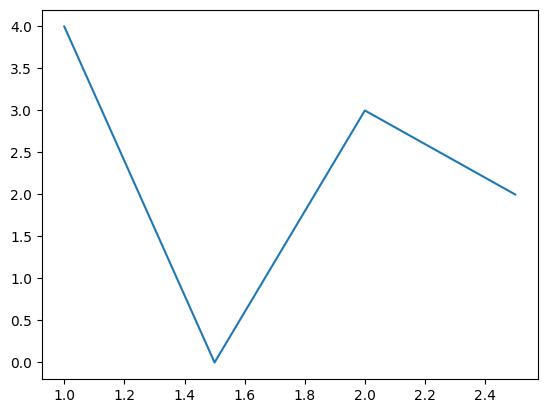

In [9]:
import torch
import matplotlib.pyplot as plt
xx = torch.tensor([[1,1,3], [3,2,2], [2,1,1]], dtype=torch.float32)
hy,hx = torch.histogram(xx, bins=4)
print("histogram counts:", hy)
print("histogram bins:", hx)
print("unique values:", torch.unique(xx))
plt.plot(hx[:-1].detach(), hy.detach())